In [1]:
import os
import pandas as pd

# Função auxiliar pra evitar repetir código
def load_files_by_year(suffix):
    df_list = []
    # Loop de 2015 a 2025
    for year in range(2014, 2026):
        file_path = f"../../data/08_lead_lag/leadlag_df_{year}_{suffix}.csv"
        # Só lê se o arquivo existir na pasta
        if os.path.exists(file_path):
            df_list.append(pd.read_csv(file_path, index_col=0))
    return pd.concat(df_list)

# Carregando as diferentes variações
df1 = load_files_by_year(5)

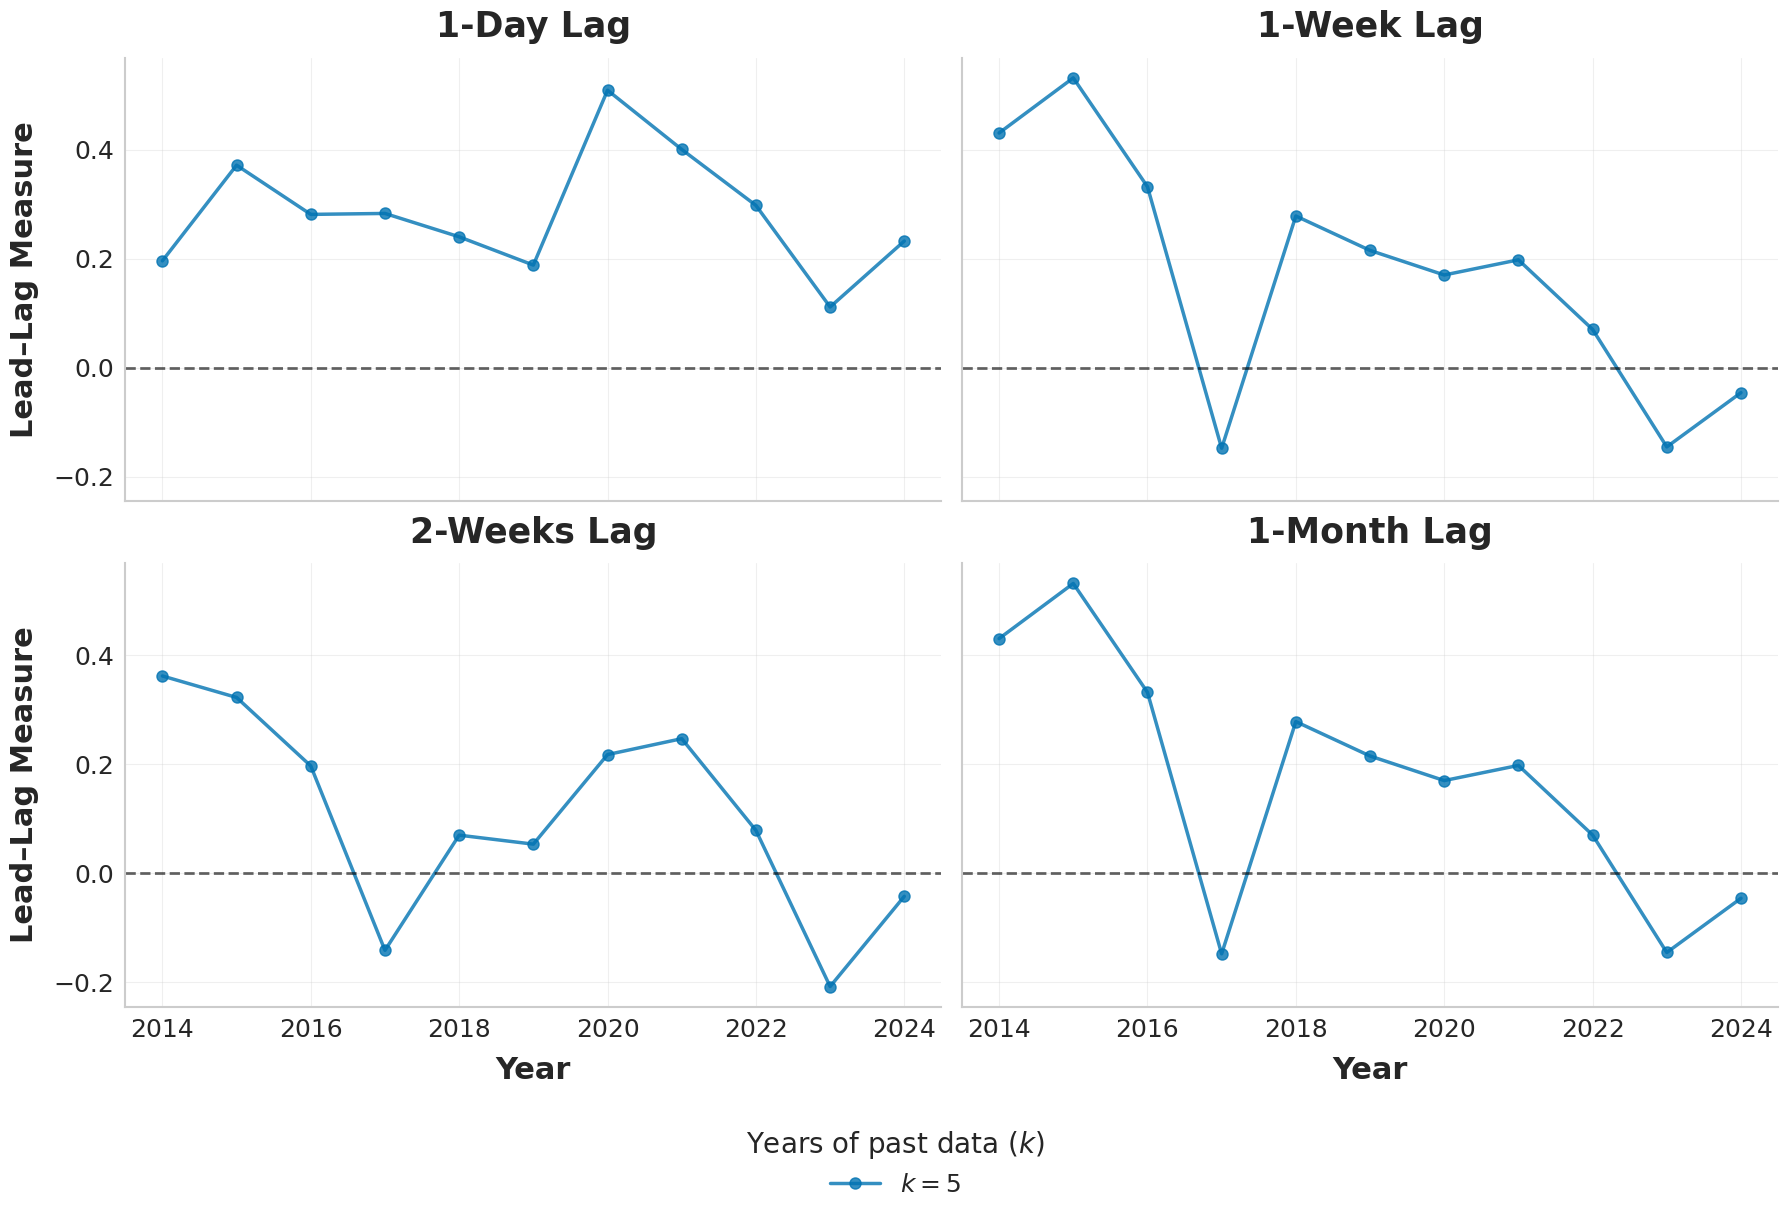

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Style Configuration for Paper ---
sns.set_theme(style="whitegrid", context="paper")
palette = sns.color_palette("colorblind")

# --- FONT SIZE CONFIGURATION ---
TITLE_SIZE = 25
LABEL_SIZE = 22
TICK_SIZE = 18
LEGEND_SIZE = 18
LINE_WIDTH = 2.5
MARKER_SIZE = 8

# --- Figure ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey=True)
axes_flat = axes.flatten()

panels = [
    ("cp1d", "ls1", "1-Day Lag"),
    ("cp1w", "ls2", "1-Week Lag"),
    ("cp2w", "ls3", "2-Weeks Lag"),
    ("cp1m", "ls4", "1-Month Lag"),
]

for i, (ax, (col_cp, col_ls, title)) in enumerate(zip(axes_flat, panels)):
    # Plot k=5
    l1, = ax.plot(
        df1.index, df1[col_cp],
        lw=LINE_WIDTH, color=palette[0],
        label="$k = 5$",
        marker="o", markersize=MARKER_SIZE,
        alpha=0.8
    )

    # Subplot Titles and Ticks
    ax.set_title(title, fontsize=TITLE_SIZE, fontweight="bold", pad=15)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    
    # Baseline
    ax.axhline(0, color="black", linewidth=2, linestyle="--", alpha=0.6)
    
    # Axis Labels
    if i >= 2: # Bottom row
        ax.set_xlabel("Year", fontsize=LABEL_SIZE, fontweight="bold", labelpad=10)
    
    if i % 2 == 0: # Left column
        ax.set_ylabel("Lead–Lag Measure", fontsize=LABEL_SIZE, fontweight="bold", labelpad=10)

    ax.grid(alpha=0.3)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

# -------- Single shared legend below all panels --------
handles = [l1]
fig.legend(
    handles,
    [h.get_label() for h in handles],
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=LEGEND_SIZE,
    title="Years of past data ($k$)",
    title_fontsize=LEGEND_SIZE + 2,
    bbox_to_anchor=(0.5, -0.02),
)

# -------- Final polish --------
sns.despine(fig=fig)
# Adjust rect to leave space for the global legend at the bottom
plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig("../../figures/leadlag_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
import os
import pandas as pd

# Função auxiliar pra evitar repetir código
def load_files_mcap():
    df_list = []
    # Loop de 2015 a 2025
    for year in range(2015, 2026):
        file_path = f"../../data/08_lead_lag/marketcap_leadlag_df_{year}.csv"
        # Só lê se o arquivo existir na pasta
        if os.path.exists(file_path):
            df_list.append(pd.read_csv(file_path, index_col=0))
    return pd.concat(df_list)

# Carregando as diferentes variações
df_mcap = load_files_mcap()

In [17]:
df_mcap

,ls1d,ls1w,ls2w,ls1m
2015,-0.091985,-0.099372,-0.116267,-0.108881
2016,-0.082557,-0.101235,-0.096282,-0.098688
2017,-0.064492,-0.104122,-0.103934,-0.101725
2018,-0.045373,-0.062040,-0.086272,-0.013130
2019,-0.034277,-0.020927,0.000840,0.015865
2020,-0.040601,0.043985,-0.186469,-0.045378
2021,-0.033748,0.029825,-0.198023,-0.031361
2022,-0.035098,0.010477,-0.195309,-0.047091
2023,-0.044168,-0.005605,-0.197154,-0.030796
2024,-0.035927,-0.009498,-0.199481,-0.039394


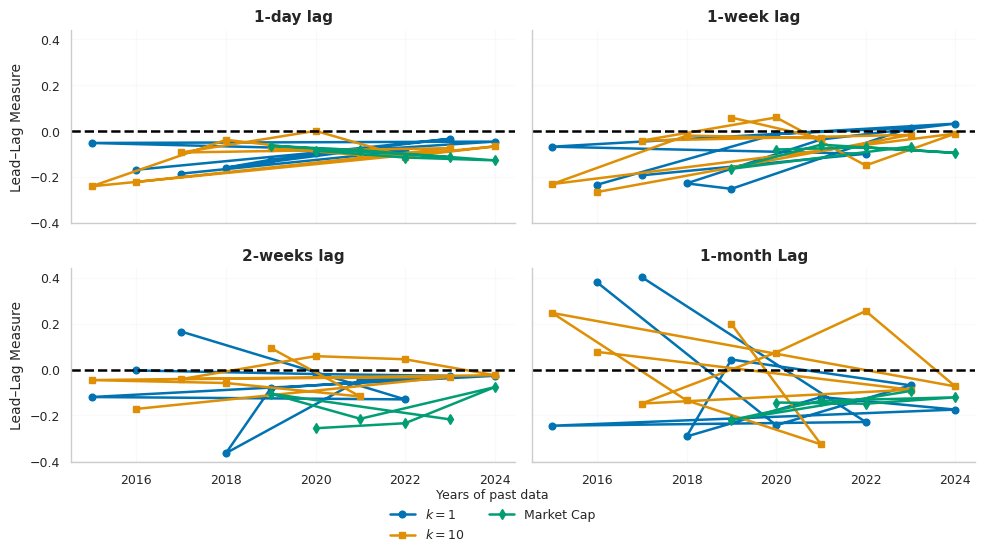

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Style ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = sns.color_palette("colorblind")

# --- Figure ---
fig, axes = plt.subplots(2, 2, figsize=(10, 5.5), sharex=True, sharey=True)
axes_flat = axes.flatten()  # ✦ key fix: iterate over individual axes

# -------- Panel config --------
panels = [
    ("cp1d", "ls1", "1-day lag"),
    ("cp1w", "ls2", "1-week lag"),
    ("cp2w", "ls3", "2-weeks lag"),
    ("cp1m", "ls4", "1-month Lag"),
]

for i, (ax, (col_cp, col_ls, title)) in enumerate(zip(axes_flat, panels)):
    l1, = ax.plot(
        df1.index, df1[col_cp],
        lw=1.8, color=palette[0],
        label="$k = 1$",
        marker="o"
    )

    l2, = ax.plot(
        df10.index, df10[col_cp],
        lw=1.8, color=palette[1],
        label="$k = 10$",
        marker="s"
    )

    l3, = ax.plot(
        dfmcap.index, dfmcap[col_cp],
        lw=1.8, color=palette[2],
        label="Market Cap",
        marker="d"
    )

    ax.set_title(title, fontsize=11, fontweight="bold", pad=6)
    ax.tick_params(axis="both", labelsize=9)
    ax.axhline(0, color="black", linewidth=1.8, linestyle="--")
    ax.set_xlabel("")

    # ✦ Only left-column panels get a y-label
    if i % 2 == 0:
        ax.set_ylabel("Lead–Lag Measure", fontsize=10)
    else:
        ax.set_ylabel("")
    
    ax.grid(alpha=0.1)

# -------- Single shared legend below all panels --------
handles = [l1, l2, l3]
fig.legend(
    handles,
    [h.get_label() for h in handles],
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=9,
    title="Years of past data",
    title_fontsize=9,
    bbox_to_anchor=(0.5, -0.02),
)

# -------- Final polish --------
sns.despine(fig=fig)
plt.tight_layout(rect=[0, 0.07, 1, 1])
# plt.savefig(f"../../figures/leadlag_over_time.png", dpi=300)
plt.show()